# Somnia Notebook 02 : Preprocessing

**Objectif :** Transformer les signaux bruts en features prêtes pour le ML

**Partie A — EEG (Sleep-EDF)**
1. Chargement et filtrage des époques annotées
2. Suppression des Wake hors-sommeil
3. Extraction de 16 features temporelles + spectrales
4. Split train/val/test + sauvegarde

**Partie B — ECG (Apnea-ECG)**
1. Segmentation en fenêtres de 1 minute
2. Extraction features ECG (RR intervals + HRV + statistiques)
3. Split train/val/test + sauvegarde

**Auteur :** Marine Deldicque  
**Contexte :** AIA Jedha — Bloc 4

## 0. Imports et configuration

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import mne
import wfdb
from scipy import signal as scipy_signal
from scipy.signal import welch, find_peaks
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

# Chemins
DATA_RAW_EEG  = Path('../data/raw')
DATA_RAW_ECG  = Path('../data/raw_apnea')
DATA_PROC_EEG = Path('../data/processed/eeg')
DATA_PROC_ECG = Path('../data/processed/ecg')
DATA_PROC_EEG.mkdir(parents=True, exist_ok=True)
DATA_PROC_ECG.mkdir(parents=True, exist_ok=True)

# Constantes EEG
FS_EEG      = 100       # Hz
EPOCH_LEN   = 30        # secondes
EPOCH_SAMPLES = FS_EEG * EPOCH_LEN  # 3000 échantillons

# Constantes ECG
FS_ECG      = 100       # Hz
SEGMENT_LEN = 60        # secondes
SEG_SAMPLES = FS_ECG * SEGMENT_LEN  # 6000 échantillons

# Mapping stades
STAGE_MAPPING = {
    'Sleep stage W' : 0,
    'Sleep stage 1' : 1,
    'Sleep stage 2' : 2,
    'Sleep stage 3' : 3,
    'Sleep stage 4' : 3,
    'Sleep stage R' : 4,
    'Movement time' : 0,
}
STAGE_NAMES = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}

PALETTE = ['#2E4057', '#048A81', '#54C6EB', '#EF8354', '#E84855']

print('Imports OK')
print(f'EEG processed → {DATA_PROC_EEG.resolve()}')
print(f'ECG processed → {DATA_PROC_ECG.resolve()}')

Imports OK
EEG processed → /Users/marinedeldicque/Library/Mobile Documents/com~apple~CloudDocs/JEDHA/DATA SCIENCE LEAD/aia/bloc 4 projet final/somnia/data/processed/eeg
ECG processed → /Users/marinedeldicque/Library/Mobile Documents/com~apple~CloudDocs/JEDHA/DATA SCIENCE LEAD/aia/bloc 4 projet final/somnia/data/processed/ecg


---
# PARTIE A Preprocessing EEG (Stades de sommeil)

## A1. Chargement des époques + suppression Wake hors-sommeil

**Stratégie :**
- On détecte le **premier endormissement** (première époque non-Wake)
- On détecte le **dernier réveil** (dernière époque non-Wake)
- On ne garde que les époques entre ces deux bornes
- Wake **à l'intérieur** du sommeil (micro-réveils) est conservé
- Résultat attendu : Wake passe de ~68% à ~10-15%

In [29]:
def load_eeg_epochs(psg_file, hyp_file, channel='EEG Fpz-Cz'):
    """
    Charge toutes les époques EEG annotées d'un sujet.
    
    Returns
    -------
    epochs : list of np.array (3000,)
    labels : list of int (0-4)
    """
    # Charger le signal EEG
    raw = mne.io.read_raw_edf(psg_file, include=[channel], preload=True, verbose=False)
    data, _ = raw[channel]
    data = data[0]
    fs = int(raw.info['sfreq'])
    
    # Charger les annotations
    annot = mne.read_annotations(hyp_file)
    
    epochs, labels = [], []
    
    for a in annot:
        desc = a['description']
        if desc not in STAGE_MAPPING:
            continue
        stage = STAGE_MAPPING[desc]
        n_epochs = int(round(a['duration'] / EPOCH_LEN))
        onset_s = int(a['onset'] * fs)
        
        for i in range(n_epochs):
            start = onset_s + i * EPOCH_SAMPLES
            end   = start + EPOCH_SAMPLES
            if end <= len(data):
                epochs.append(data[start:end])
                labels.append(stage)
    
    return epochs, labels


def trim_wake_outside_sleep(epochs, labels):
    """
    Supprime les époques Wake avant le premier endormissement
    et après le dernier réveil.
    Conserve les micro-réveils à l'intérieur du sommeil.
    """
    labels_arr = np.array(labels)
    
    # Trouver les bornes du sommeil
    sleep_indices = np.where(labels_arr != 0)[0]
    
    if len(sleep_indices) == 0:
        return epochs, labels  # Pas de sommeil → garder tel quel
    
    first_sleep = sleep_indices[0]
    last_sleep  = sleep_indices[-1]
    
    # Garder uniquement les époques dans la fenêtre de sommeil
    epochs_trimmed = epochs[first_sleep:last_sleep + 1]
    labels_trimmed = labels_arr[first_sleep:last_sleep + 1].tolist()
    
    return epochs_trimmed, labels_trimmed


print('Fonctions de chargement définies')

Fonctions de chargement définies


In [30]:
# Charger tous les sujets
psg_files = sorted(DATA_RAW_EEG.glob('*PSG.edf'))
hyp_files = sorted(DATA_RAW_EEG.glob('*Hypnogram.edf'))

# Associer PSG ↔ Hypnogram par identifiant sujet
psg_dict = {f.name[:7]: f for f in psg_files}
hyp_dict = {f.name[:7]: f for f in hyp_files}
common_subjects = sorted(set(psg_dict.keys()) & set(hyp_dict.keys()))

print(f'Sujets avec PSG + Hypnogram : {len(common_subjects)}')
print(f'Sujets ignorés (pas de paire) : {len(psg_files) - len(common_subjects)}')
print()

all_epochs, all_labels = [], []
stats_list = []

for subj in common_subjects:
    print(f'  Chargement {subj}...', end=' ')
    
    try:
        epochs, labels = load_eeg_epochs(psg_dict[subj], hyp_dict[subj])
        n_before = len(epochs)
        
        epochs, labels = trim_wake_outside_sleep(epochs, labels)
        n_after = len(epochs)
        
        wake_pct = sum(l == 0 for l in labels) / len(labels) * 100 if labels else 0
        print(f'{n_before} → {n_after} époques | Wake : {wake_pct:.0f}%')
        
        all_epochs.extend(epochs)
        all_labels.extend(labels)
        stats_list.append({'subject': subj, 'n_before': n_before,
                            'n_after': n_after, 'wake_pct': wake_pct})
    except Exception as e:
        print(f'Erreur : {e}')

print(f'\nTotal époques chargées : {len(all_epochs):,}')
print(f'   Labels : {len(all_labels):,}')

Sujets avec PSG + Hypnogram : 28
Sujets ignorés (pas de paire) : 2

  Chargement SC4001E... 2650 → 721 époques | Wake : 9%
  Chargement SC4002E... 2830 → 1008 époques | Wake : 6%
  Chargement SC4011E... 2802 → 983 époques | Wake : 4%
  Chargement SC4012E... 2848 → 1066 époques | Wake : 4%
  Chargement SC4021E... 2804 → 905 époques | Wake : 1%
  Chargement SC4022E... 2756 → 890 époques | Wake : 1%
  Chargement SC4031E... 2820 → 832 époques | Wake : 2%
  Chargement SC4041E... 2570 → 1116 époques | Wake : 7%
  Chargement SC4042E... 2792 → 1084 époques | Wake : 6%
  Chargement SC4051E... 2722 → 552 époques | Wake : 16%
  Chargement SC4052E... 2806 → 1128 époques | Wake : 9%
  Chargement SC4061E... 2770 → 723 époques | Wake : 3%
  Chargement SC4062E... 2830 → 896 époques | Wake : 8%
  Chargement SC4071E... 2810 → 856 époques | Wake : 0%
  Chargement SC4072E... 2770 → 1153 époques | Wake : 25%
  Chargement SC4081E... 2796 → 1014 époques | Wake : 20%
  Chargement SC4082E... 2634 → 934 époques

Distribution APRÈS suppression Wake hors-sommeil :
   Wake  : 1,621 ( 6.3%) ██████
   N1    : 2,059 ( 8.0%) ████████
   N2    : 12,807 (49.8%) █████████████████████████████████████████████████
   N3    : 3,941 (15.3%) ███████████████
   REM   : 5,293 (20.6%) ████████████████████


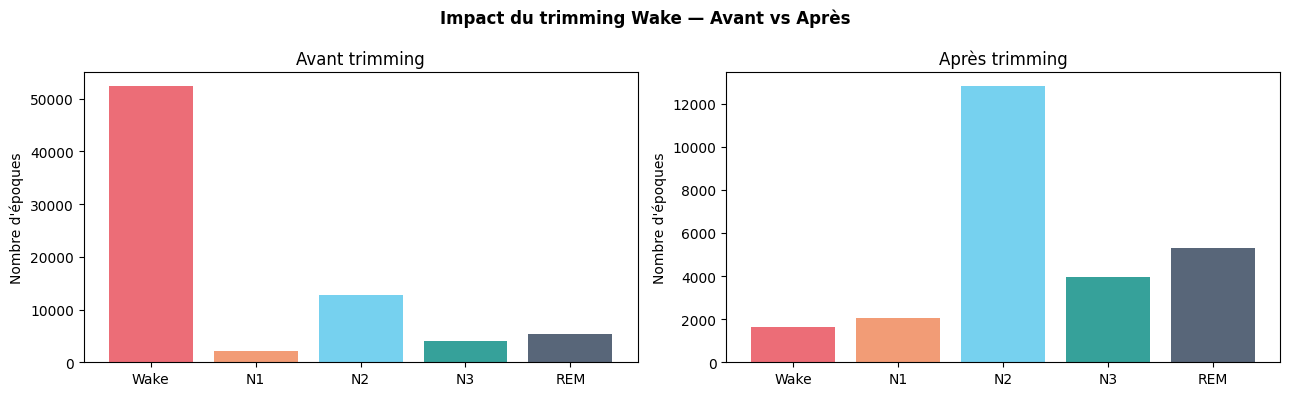

In [31]:
# Vérifier la nouvelle distribution
labels_series = pd.Series(all_labels)
dist_after = labels_series.value_counts().sort_index()
dist_pct   = dist_after / dist_after.sum() * 100

print('Distribution APRÈS suppression Wake hors-sommeil :')
for idx in dist_after.index:
    bar = '█' * int(dist_pct[idx])
    print(f'   {STAGE_NAMES[idx]:5s} : {dist_after[idx]:5,} ({dist_pct[idx]:4.1f}%) {bar}')

# Visualisation avant/après
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Impact du trimming Wake — Avant vs Après', fontsize=12, fontweight='bold')

dist_before_raw = [52347, 2059, 12807, 3941, 5293]  # valeurs notebook 01
dist_after_raw  = [dist_after.get(i, 0) for i in range(5)]
names = [STAGE_NAMES[i] for i in range(5)]
colors = ['#E84855', '#EF8354', '#54C6EB', '#048A81', '#2E4057']

axes[0].bar(names, dist_before_raw, color=colors, alpha=0.8)
axes[0].set_title('Avant trimming')
axes[0].set_ylabel('Nombre d\'époques')

axes[1].bar(names, dist_after_raw, color=colors, alpha=0.8)
axes[1].set_title('Après trimming')
axes[1].set_ylabel('Nombre d\'époques')

plt.tight_layout()
plt.savefig('../data/figures/wake_trimming_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## A2. Extraction des features EEG (16 features)

Pour chaque époque de 30s (3000 points), on extrait :
- **8 statistiques temporelles** : mean, std, min, max, Q1, Q3, skewness, kurtosis
- **5 puissances spectrales** : Delta, Theta, Alpha, Beta, Gamma
- **3 ratios de puissance** : delta/total, theta/total, alpha/total

In [32]:
def extract_eeg_features(epoch, fs=100):
    """
    Extrait 16 features d'une époque EEG de 30s.
    
    Parameters
    ----------
    epoch : np.array (3000,) — signal en Volts
    fs    : int — fréquence d'échantillonnage
    
    Returns
    -------
    features : np.array (16,)
    """
    features = []
    
    # Conversion V → µV (nécessaire pour avoir des valeurs numériquement exploitables)
    epoch_uv = epoch * 1e6
    
    # === 1. Statistiques temporelles (8 features) ===
    features.append(np.mean(epoch_uv))           # Amplitude moyenne
    features.append(np.std(epoch_uv))            # Écart-type
    features.append(np.min(epoch_uv))            # Min
    features.append(np.max(epoch_uv))            # Max
    features.append(np.percentile(epoch_uv, 25)) # Q1
    features.append(np.percentile(epoch_uv, 75)) # Q3
    features.append(stats.skew(epoch_uv))        # Asymétrie
    features.append(stats.kurtosis(epoch_uv))    # Aplatissement
    
    # === 2. Analyse spectrale (5 features) ===
    freqs, psd = welch(epoch_uv, fs=fs, nperseg=256)
    
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta' : (13, 30),
        'gamma': (30, 35),
    }
    
    band_powers = {}
    for name, (fmin, fmax) in bands.items():
        mask = (freqs >= fmin) & (freqs < fmax)
        band_powers[name] = np.mean(psd[mask]) if mask.any() else 0
        features.append(band_powers[name])
    
    # === 3. Ratios de puissance (3 features) ===
    total = sum(band_powers.values())
    if total > 0:
        features.append(band_powers['delta'] / total)  # Ratio delta
        features.append(band_powers['theta'] / total)  # Ratio theta
        features.append(band_powers['alpha'] / total)  # Ratio alpha
    else:
        features.extend([0, 0, 0])
    
    return np.array(features, dtype=np.float32)


# Noms des features (pour SHAP et interprétabilité)
FEATURE_NAMES_EEG = [
    'mean', 'std', 'min', 'max', 'q25', 'q75', 'skewness', 'kurtosis',
    'delta_power', 'theta_power', 'alpha_power', 'beta_power', 'gamma_power',
    'delta_ratio', 'theta_ratio', 'alpha_ratio'
]

# Test sur une époque
test_epoch = all_epochs[0]
test_features = extract_eeg_features(test_epoch)
print(f'Extraction OK — Shape : {test_features.shape}')
print()
print('Features extraites :')
for name, val in zip(FEATURE_NAMES_EEG, test_features):
    print(f'   {name:15s} : {val:.6f}')

Extraction OK — Shape : (16,)

Features extraites :
   mean            : 0.230244
   std             : 8.876442
   min             : -31.929670
   max             : 48.246155
   q25             : -5.579487
   q75             : 5.579487
   skewness        : 0.210865
   kurtosis        : 1.269998
   delta_power     : 11.358530
   theta_power     : 5.080435
   alpha_power     : 1.733061
   beta_power      : 0.198112
   gamma_power     : 0.068446
   delta_ratio     : 0.616020
   theta_ratio     : 0.275533
   alpha_ratio     : 0.093991


In [33]:
# Extraction pour toutes les époques
print(f'Extraction de {len(all_epochs):,} époques...')
print('(peut prendre 1-2 minutes)')

X_eeg = np.array([
    extract_eeg_features(epoch)
    for epoch in all_epochs
], dtype=np.float32)

y_eeg = np.array(all_labels, dtype=np.int32)

print(f'\nExtraction terminée !')
print(f'   X_eeg shape : {X_eeg.shape}  (n_samples, n_features)')
print(f'   y_eeg shape : {y_eeg.shape}')
print(f'   NaN count   : {np.isnan(X_eeg).sum()}')
print(f'   Inf count   : {np.isinf(X_eeg).sum()}')

# Remplacer NaN/Inf si besoin
X_eeg = np.nan_to_num(X_eeg, nan=0.0, posinf=0.0, neginf=0.0)

Extraction de 25,721 époques...
(peut prendre 1-2 minutes)

Extraction terminée !
   X_eeg shape : (25721, 16)  (n_samples, n_features)
   y_eeg shape : (25721,)
   NaN count   : 0
   Inf count   : 0


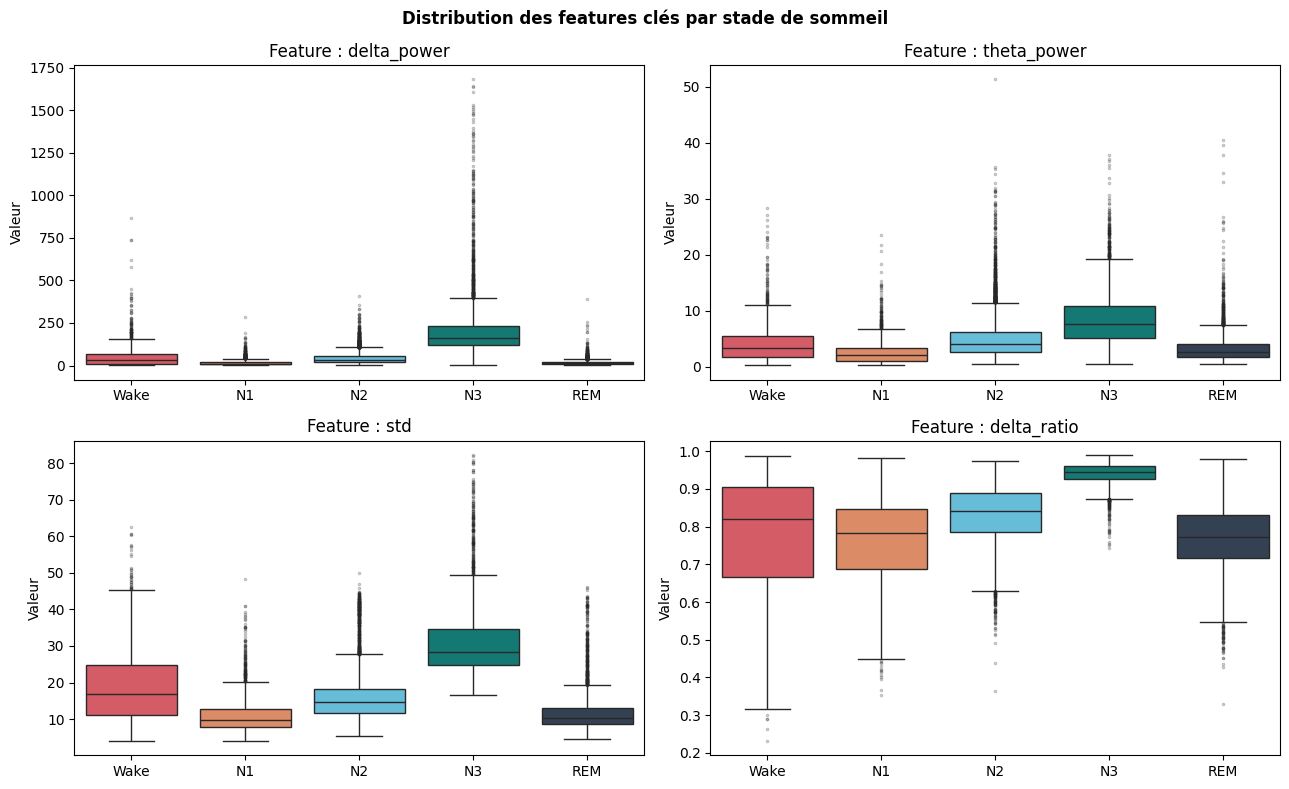

Figure sauvegardée


In [34]:
# Visualisation des features par stade (boxplots)
df_features = pd.DataFrame(X_eeg, columns=FEATURE_NAMES_EEG)
df_features['stage'] = [STAGE_NAMES[l] for l in y_eeg]

# Les 4 features les plus discriminantes
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribution des features clés par stade de sommeil', fontsize=12, fontweight='bold')

key_features = ['delta_power', 'theta_power', 'std', 'delta_ratio']
stage_order  = ['Wake', 'N1', 'N2', 'N3', 'REM']
palette      = {'Wake': '#E84855', 'N1': '#EF8354', 'N2': '#54C6EB',
                'N3': '#048A81', 'REM': '#2E4057'}

for ax, feat in zip(axes.flat, key_features):
    sns.boxplot(data=df_features, x='stage', y=feat,
                order=stage_order, palette=palette, ax=ax,
                flierprops={'marker': '.', 'alpha': 0.3, 'markersize': 3})
    ax.set_title(f'Feature : {feat}')
    ax.set_xlabel('')
    ax.set_ylabel('Valeur')

plt.tight_layout()
plt.savefig('../data/figures/eeg_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée')

## A3. Split train/val/test + sauvegarde

In [35]:
# Split stratifié : 70% train / 15% val / 15% test
X_train_eeg, X_temp, y_train_eeg, y_temp = train_test_split(
    X_eeg, y_eeg,
    test_size=0.30,
    random_state=42,
    stratify=y_eeg
)

X_val_eeg, X_test_eeg, y_val_eeg, y_test_eeg = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print('Split EEG :')
print(f'   Train : {X_train_eeg.shape[0]:,} échantillons ({X_train_eeg.shape[0]/len(X_eeg)*100:.0f}%)')
print(f'   Val   : {X_val_eeg.shape[0]:,} échantillons ({X_val_eeg.shape[0]/len(X_eeg)*100:.0f}%)')
print(f'   Test  : {X_test_eeg.shape[0]:,} échantillons ({X_test_eeg.shape[0]/len(X_eeg)*100:.0f}%)')

# Vérifier la stratification
print('\nDistribution y_train :')
for stage, count in zip(*np.unique(y_train_eeg, return_counts=True)):
    print(f'   {STAGE_NAMES[stage]:5s} : {count:5,} ({count/len(y_train_eeg)*100:.1f}%)')

Split EEG :
   Train : 18,004 échantillons (70%)
   Val   : 3,858 échantillons (15%)
   Test  : 3,859 échantillons (15%)

Distribution y_train :
   Wake  : 1,135 (6.3%)
   N1    : 1,441 (8.0%)
   N2    : 8,964 (49.8%)
   N3    : 2,759 (15.3%)
   REM   : 3,705 (20.6%)


In [36]:
# Sauvegarde
np.save(DATA_PROC_EEG / 'X_train.npy', X_train_eeg)
np.save(DATA_PROC_EEG / 'X_val.npy',   X_val_eeg)
np.save(DATA_PROC_EEG / 'X_test.npy',  X_test_eeg)
np.save(DATA_PROC_EEG / 'y_train.npy', y_train_eeg)
np.save(DATA_PROC_EEG / 'y_val.npy',   y_val_eeg)
np.save(DATA_PROC_EEG / 'y_test.npy',  y_test_eeg)

# Sauvegarder les noms de features et métadonnées
metadata_eeg = {
    'feature_names': FEATURE_NAMES_EEG,
    'stage_names'  : STAGE_NAMES,
    'fs'           : FS_EEG,
    'epoch_len'    : EPOCH_LEN,
    'n_features'   : len(FEATURE_NAMES_EEG),
    'n_classes'    : 5,
    'n_subjects'   : len(common_subjects),
}
joblib.dump(metadata_eeg, DATA_PROC_EEG / 'metadata.pkl')

print('Données EEG sauvegardées :')
for f in sorted(DATA_PROC_EEG.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f'   {f.name:20s} — {size_kb:.0f} Ko')

Données EEG sauvegardées :
   X_test.npy           — 241 Ko
   X_train.npy          — 1125 Ko
   X_val.npy            — 241 Ko
   metadata.pkl         — 0 Ko
   y_test.npy           — 15 Ko
   y_train.npy          — 70 Ko
   y_val.npy            — 15 Ko


---
# PARTIE B Preprocessing ECG (Détection apnées)

## B1. Extraction des features ECG

Pour chaque segment de 1 minute (6000 points), on extrait :
- **5 statistiques du signal brut** : mean, std, min, max, range
- **5 features RR intervals** : mean_RR, std_RR, min_RR, max_RR, RMSSD
- **3 features HRV fréquentielles** : LF power, HF power, LF/HF ratio
- **3 features morphologie QRS** : mean amplitude, std amplitude, n_peaks

→ **16 features ECG** (symétrique avec EEG pour cohérence)

In [37]:
def extract_rr_intervals(ecg_segment, fs=100):
    """
    Détecte les pics R et calcule les intervalles RR.
    
    Returns
    -------
    rr_intervals : np.array — intervalles RR en secondes
    peaks        : np.array — indices des pics R
    """
    # Normaliser le signal
    ecg_norm = (ecg_segment - np.mean(ecg_segment)) / (np.std(ecg_segment) + 1e-8)
    
    # Détecter les pics R (distance min = 0.3s = 30 samples à 100Hz → ~200 BPM max)
    peaks, _ = find_peaks(ecg_norm, height=0.5, distance=int(0.3 * fs))
    
    if len(peaks) < 2:
        return np.array([]), peaks
    
    rr_intervals = np.diff(peaks) / fs  # en secondes
    
    # Filtrer les RR aberrants (< 0.3s ou > 2s)
    rr_intervals = rr_intervals[(rr_intervals > 0.3) & (rr_intervals < 2.0)]
    
    return rr_intervals, peaks


def extract_ecg_features(ecg_segment, fs=100):
    """
    Extrait 16 features d'un segment ECG de 1 minute.
    
    Parameters
    ----------
    ecg_segment : np.array (6000,)
    fs          : int
    
    Returns
    -------
    features : np.array (16,)
    """
    features = []
    
    # === 1. Statistiques signal brut (5 features) ===
    features.append(np.mean(ecg_segment))
    features.append(np.std(ecg_segment))
    features.append(np.min(ecg_segment))
    features.append(np.max(ecg_segment))
    features.append(np.max(ecg_segment) - np.min(ecg_segment))  # range
    
    # === 2. Features RR intervals (5 features) ===
    rr, peaks = extract_rr_intervals(ecg_segment, fs)
    
    if len(rr) >= 2:
        features.append(np.mean(rr))                      # mean_RR
        features.append(np.std(rr))                       # std_RR (SDNN)
        features.append(np.min(rr))                       # min_RR
        features.append(np.max(rr))                       # max_RR
        features.append(np.sqrt(np.mean(np.diff(rr)**2))) # RMSSD
    else:
        features.extend([0.8, 0.05, 0.6, 1.2, 0.05])     # valeurs par défaut
    
    # === 3. HRV fréquentielle (3 features) ===
    if len(rr) >= 4:
        # Rééchantillonner les RR à 4 Hz pour l'analyse fréquentielle
        rr_times = np.cumsum(rr)
        t_uniform = np.arange(0, rr_times[-1], 0.25)  # 4 Hz
        rr_uniform = np.interp(t_uniform, rr_times, rr)
        
        if len(rr_uniform) > 8:
            freqs_hrv, psd_hrv = welch(rr_uniform, fs=4, nperseg=min(len(rr_uniform), 64))
            lf_mask = (freqs_hrv >= 0.04) & (freqs_hrv < 0.15)
            hf_mask = (freqs_hrv >= 0.15) & (freqs_hrv < 0.40)
            lf_power = np.sum(psd_hrv[lf_mask]) if lf_mask.any() else 0
            hf_power = np.sum(psd_hrv[hf_mask]) if hf_mask.any() else 0
            lf_hf    = lf_power / (hf_power + 1e-8)
            features.extend([lf_power, hf_power, lf_hf])
        else:
            features.extend([0, 0, 1])
    else:
        features.extend([0, 0, 1])
    
    # === 4. Morphologie QRS (3 features) ===
    if len(peaks) > 0:
        amplitudes = ecg_segment[peaks]
        features.append(np.mean(amplitudes))   # amplitude moyenne QRS
        features.append(np.std(amplitudes))    # variabilité amplitude
        features.append(len(peaks) / (len(ecg_segment) / fs / 60))  # BPM estimé
    else:
        features.extend([0, 0, 60])
    
    return np.array(features[:16], dtype=np.float32)  # S'assurer d'avoir exactement 16


FEATURE_NAMES_ECG = [
    'ecg_mean', 'ecg_std', 'ecg_min', 'ecg_max', 'ecg_range',
    'mean_RR', 'std_RR', 'min_RR', 'max_RR', 'RMSSD',
    'LF_power', 'HF_power', 'LF_HF_ratio',
    'qrs_amplitude_mean', 'qrs_amplitude_std', 'heart_rate_bpm'
]

# Test
subj_test = 'a01'
rec_test  = wfdb.rdrecord(str(DATA_RAW_ECG / subj_test))
ecg_test  = rec_test.p_signal[:SEG_SAMPLES, 0]
feats_test = extract_ecg_features(ecg_test)

print(f'Extraction ECG OK — Shape : {feats_test.shape}')
print()
for name, val in zip(FEATURE_NAMES_ECG, feats_test):
    print(f'   {name:25s} : {val:.4f}')

Extraction ECG OK — Shape : (16,)

   ecg_mean                  : -0.0009
   ecg_std                   : 0.2552
   ecg_min                   : -0.8850
   ecg_max                   : 1.7500
   ecg_range                 : 2.6350
   mean_RR                   : 0.9000
   std_RR                    : 0.0592
   min_RR                    : 0.7700
   max_RR                    : 1.0200
   RMSSD                     : 0.0417
   LF_power                  : 0.0248
   HF_power                  : 0.0119
   LF_HF_ratio               : 2.0889
   qrs_amplitude_mean        : 1.5040
   qrs_amplitude_std         : 0.1379
   heart_rate_bpm            : 67.0000


## B2. Extraction pour tous les sujets

In [39]:
def load_ecg_subject(subj_id, data_dir, fs=100, seg_len=60):
    """
    Charge un sujet ECG et retourne les segments avec labels.
    
    Returns
    -------
    segments : list of np.array (6000,)
    labels   : list of int (0=Normal, 1=Apnée)
    """
    rec  = wfdb.rdrecord(str(data_dir / subj_id))
    ann  = wfdb.rdann(str(data_dir / subj_id), 'apn')
    ecg  = rec.p_signal[:, 0]
    seg_samples = fs * seg_len
    
    segments, labels = [], []
    label_map = {'A': 1, 'N': 0}
    
    for i, sym in enumerate(ann.symbol):
        if sym not in label_map:
            continue
        start = i * seg_samples
        end   = start + seg_samples
        if end <= len(ecg):
            segments.append(ecg[start:end])
            labels.append(label_map[sym])
    
    return segments, labels


# Charger tous les sujets ECG
subjects_ecg = sorted([f.stem for f in DATA_RAW_ECG.glob('*.dat')])
print(f'Sujets ECG : {subjects_ecg}')

all_ecg_segments, all_ecg_labels = [], []

for subj in subjects_ecg:
    try:
        segs, labs = load_ecg_subject(subj, DATA_RAW_ECG)
        n_apnea  = sum(l == 1 for l in labs)
        n_normal = sum(l == 0 for l in labs)
        print(f'   {subj} : {len(segs)} segments | Apnée={n_apnea} Normal={n_normal}')
        all_ecg_segments.extend(segs)
        all_ecg_labels.extend(labs)
    except Exception as e:
        print(f'   {subj} : ❌ {e}')

print(f'\n Total segments ECG : {len(all_ecg_segments):,}')
n_apnea_total  = sum(l == 1 for l in all_ecg_labels)
n_normal_total = sum(l == 0 for l in all_ecg_labels)
print(f'   Apnée  : {n_apnea_total} ({n_apnea_total/len(all_ecg_labels)*100:.1f}%)')
print(f'   Normal : {n_normal_total} ({n_normal_total/len(all_ecg_labels)*100:.1f}%)')

Sujets ECG : ['a01', 'a02', 'a03', 'a04', 'a05', 'a06', 'a07', 'a08', 'a09', 'a10', 'a11', 'a12', 'a13', 'a14', 'a15', 'a16', 'a17', 'a18', 'b01', 'b02', 'b03', 'b04', 'b05', 'c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c08', 'c10']
   a01 : 489 segments | Apnée=470 Normal=19
   a02 : 528 segments | Apnée=420 Normal=108
   a03 : 519 segments | Apnée=246 Normal=273
   a04 : 492 segments | Apnée=453 Normal=39
   a05 : 453 segments | Apnée=276 Normal=177
   a06 : 509 segments | Apnée=206 Normal=303
   a07 : 510 segments | Apnée=321 Normal=189
   a08 : 500 segments | Apnée=189 Normal=311
   a09 : 495 segments | Apnée=381 Normal=114
   a10 : 516 segments | Apnée=99 Normal=417
   a11 : 466 segments | Apnée=222 Normal=244
   a12 : 577 segments | Apnée=534 Normal=43
   a13 : 494 segments | Apnée=243 Normal=251
   a14 : 509 segments | Apnée=383 Normal=126
   a15 : 509 segments | Apnée=368 Normal=141
   a16 : 481 segments | Apnée=320 Normal=161
   a17 : 484 segments | Apnée=158 Normal=326
   a18 :

In [40]:
# Extraction features ECG
print(f'Extraction features pour {len(all_ecg_segments):,} segments...')

X_ecg = np.array([
    extract_ecg_features(seg)
    for seg in all_ecg_segments
], dtype=np.float32)

y_ecg = np.array(all_ecg_labels, dtype=np.int32)

# Nettoyer NaN/Inf
X_ecg = np.nan_to_num(X_ecg, nan=0.0, posinf=0.0, neginf=0.0)

print(f'\n Extraction terminée !')
print(f'   X_ecg shape : {X_ecg.shape}')
print(f'   y_ecg shape : {y_ecg.shape}')
print(f'   NaN count   : {np.isnan(X_ecg).sum()}')

Extraction features pour 15,116 segments...

 Extraction terminée !
   X_ecg shape : (15116, 16)
   y_ecg shape : (15116,)
   NaN count   : 0


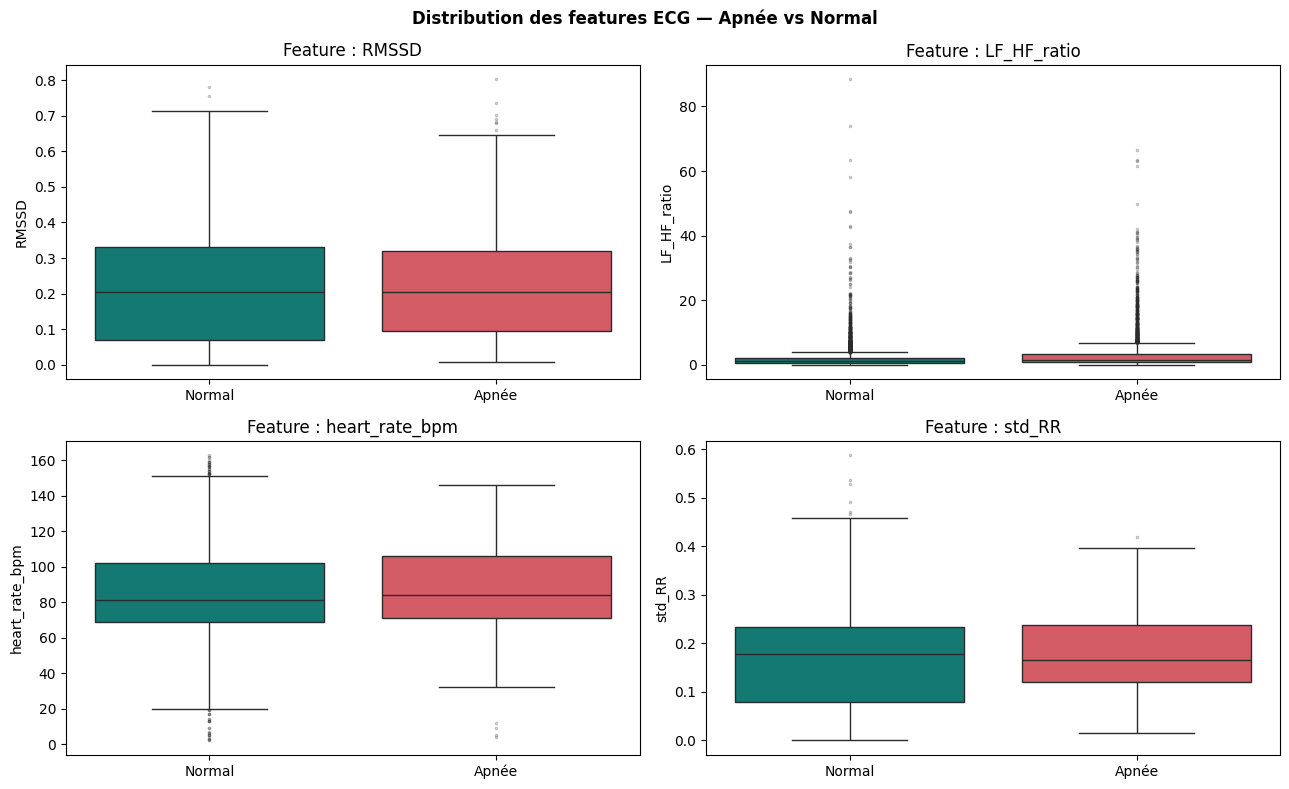

In [41]:
# Visualisation features ECG par classe
df_ecg = pd.DataFrame(X_ecg, columns=FEATURE_NAMES_ECG)
df_ecg['label'] = ['Apnée' if l == 1 else 'Normal' for l in y_ecg]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribution des features ECG — Apnée vs Normal', fontsize=12, fontweight='bold')

key_ecg_features = ['RMSSD', 'LF_HF_ratio', 'heart_rate_bpm', 'std_RR']
palette_ecg = {'Apnée': '#E84855', 'Normal': '#048A81'}

for ax, feat in zip(axes.flat, key_ecg_features):
    sns.boxplot(data=df_ecg, x='label', y=feat,
                palette=palette_ecg, ax=ax,
                flierprops={'marker': '.', 'alpha': 0.3, 'markersize': 3})
    ax.set_title(f'Feature : {feat}')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../data/figures/ecg_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## B3. Split train/val/test + sauvegarde

In [42]:
# Split stratifié
X_train_ecg, X_temp, y_train_ecg, y_temp = train_test_split(
    X_ecg, y_ecg, test_size=0.30, random_state=42, stratify=y_ecg
)
X_val_ecg, X_test_ecg, y_val_ecg, y_test_ecg = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Split ECG :')
print(f'   Train : {X_train_ecg.shape[0]:,}')
print(f'   Val   : {X_val_ecg.shape[0]:,}')
print(f'   Test  : {X_test_ecg.shape[0]:,}')

# Sauvegarde
np.save(DATA_PROC_ECG / 'X_train.npy', X_train_ecg)
np.save(DATA_PROC_ECG / 'X_val.npy',   X_val_ecg)
np.save(DATA_PROC_ECG / 'X_test.npy',  X_test_ecg)
np.save(DATA_PROC_ECG / 'y_train.npy', y_train_ecg)
np.save(DATA_PROC_ECG / 'y_val.npy',   y_val_ecg)
np.save(DATA_PROC_ECG / 'y_test.npy',  y_test_ecg)

metadata_ecg = {
    'feature_names': FEATURE_NAMES_ECG,
    'label_names'  : {0: 'Normal', 1: 'Apnée'},
    'fs'           : FS_ECG,
    'segment_len'  : SEGMENT_LEN,
    'n_features'   : len(FEATURE_NAMES_ECG),
    'n_classes'    : 2,
    'n_subjects'   : len(subjects_ecg),
}
joblib.dump(metadata_ecg, DATA_PROC_ECG / 'metadata.pkl')

print('\n Données ECG sauvegardées :')
for f in sorted(DATA_PROC_ECG.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f'   {f.name:20s} — {size_kb:.0f} Ko')

Split ECG :
   Train : 10,581
   Val   : 2,267
   Test  : 2,268

 Données ECG sauvegardées :
   X_test.npy           — 142 Ko
   X_train.npy          — 661 Ko
   X_val.npy            — 142 Ko
   metadata.pkl         — 0 Ko
   y_test.npy           — 9 Ko
   y_train.npy          — 41 Ko
   y_val.npy            — 9 Ko


---
## Synthèse du preprocessing

In [43]:
print('=' * 60)
print('SYNTHÈSE — PREPROCESSING')
print('=' * 60)

print('\n📌 PARTIE A — EEG (Stades de sommeil)')
print(f'   Époques après trimming Wake : {len(all_epochs):,}')
print(f'   Features extraites          : {len(FEATURE_NAMES_EEG)} par époque')
print(f'   X_train : {X_train_eeg.shape}')
print(f'   X_val   : {X_val_eeg.shape}')
print(f'   X_test  : {X_test_eeg.shape}')
print(f'   Fichiers → data/processed/eeg/')

print('\n📌 PARTIE B — ECG (Détection apnées)')
print(f'   Segments chargés            : {len(all_ecg_segments):,}')
print(f'   Features extraites          : {len(FEATURE_NAMES_ECG)} par segment')
print(f'   X_train : {X_train_ecg.shape}')
print(f'   X_val   : {X_val_ecg.shape}')
print(f'   X_test  : {X_test_ecg.shape}')
print(f'   Fichiers → data/processed/ecg/')

print('\n🔜 PROCHAINE ÉTAPE : Notebook 03 — Model Training')
print('   → Random Forest + MLflow tracking')
print('   → Modèle EEG (5 classes) + Modèle ECG (binaire)')
print('   → Pipeline sklearn sérialisé (.joblib)')
print('   → Rapport de classification + matrice de confusion')

SYNTHÈSE — PREPROCESSING

📌 PARTIE A — EEG (Stades de sommeil)
   Époques après trimming Wake : 25,721
   Features extraites          : 16 par époque
   X_train : (18004, 16)
   X_val   : (3858, 16)
   X_test  : (3859, 16)
   Fichiers → data/processed/eeg/

📌 PARTIE B — ECG (Détection apnées)
   Segments chargés            : 15,116
   Features extraites          : 16 par segment
   X_train : (10581, 16)
   X_val   : (2267, 16)
   X_test  : (2268, 16)
   Fichiers → data/processed/ecg/

🔜 PROCHAINE ÉTAPE : Notebook 03 — Model Training
   → Random Forest + MLflow tracking
   → Modèle EEG (5 classes) + Modèle ECG (binaire)
   → Pipeline sklearn sérialisé (.joblib)
   → Rapport de classification + matrice de confusion
